**1. Importación de librerías básicas**

In [ ]:
#Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**2. Lectura de los datos**

In [ ]:
# ─────────────────────────────────────────────
# 1. INTEGRACIÓN DE DATOS
# ─────────────────────────────────────────────
import os

# Si ya existe la muestra fija, cargarla directamente
# Si no existe, extraer del CSV completo y guardarla
if os.path.exists("muestra_sparcs_10000.csv"):
    df_raw = pd.read_csv("muestra_sparcs_10000.csv")
    print(f"Muestra fija cargada: {df_raw.shape}")
else:
    # Solo se ejecuta la primera vez
    df_target = pd.read_csv(
        "Hospital_Inpatient_Discharges.csv",
        usecols=["Length of Stay"],
        on_bad_lines='skip'
    )
    df_target["Length of Stay"] = pd.to_numeric(
        df_target["Length of Stay"], errors='coerce'
    ).fillna(0).astype(int)

    def categorizar_los(dias):
        if dias <= 3:   return "Corta"
        elif dias <= 7: return "Media"
        else:           return "Larga"

    df_target["los_cat"] = df_target["Length of Stay"].apply(categorizar_los)

    indices_muestra = df_target.groupby("los_cat", group_keys=False).apply(
        lambda x: x.sample(
            n=round(len(x) / len(df_target) * 10000),
            random_state=42
        )
    ).index

    df_raw = pd.read_csv(
        "Hospital_Inpatient_Discharges.csv",
        on_bad_lines='skip'
    ).iloc[indices_muestra].reset_index(drop=True)

    df_raw.to_csv("muestra_sparcs_10000.csv", index=False)
    print(f"Muestra extraída y guardada: {df_raw.shape}")

Muestra fija cargada: (10000, 37)


**3. Integración de datos**

**4. Eliminación de variables irreelvantes y redundantes**

In [ ]:
#Definición de variables irrelevantes:
irrelevantes = [
    "Operating Certificate Number",
    "Facility Id",
    "Facility Name",
    "Zip Code - 3 digits",
    "Discharge Year",
    "Abortion Edit Indicator",
    "Attending Provider License Number",
    "Operating Provider License Number",
    "Other Provider License Number"
]

#Eliminar irrelevantes
df = df_raw.drop(columns=irrelevantes)
print(f"Tras eliminar irrelevantes: {df.shape[1]} columnas")

#Definicón variables redundantes:
redundantes = [
    "CCS Diagnosis Description",
    "CCS Procedure Description",
    "APR DRG Description",
    "APR MDC Description",
    "APR Severity of Illness Description"
]

df = df.drop(columns=redundantes)
print(f"Tras eliminar descripciones redundantes: {df.shape[1]} columnas")

Tras eliminar irrelevantes: 28 columnas
Tras eliminar descripciones redundantes: 23 columnas


In [ ]:
#Corrección tipos de datos:
df["Age Group"]                        = df["Age Group"].astype("category")
df["Gender"]                           = df["Gender"].astype("category")
df["Race"]                             = df["Race"].astype("category")
df["Ethnicity"]                        = df["Ethnicity"].astype("category")
df["Type of Admission"]                = df["Type of Admission"].astype("category")
df["Patient Disposition"]              = df["Patient Disposition"].astype("category")
df["APR Risk of Mortality"]            = df["APR Risk of Mortality"].astype("category")
df["APR Medical Surgical Description"] = df["APR Medical Surgical Description"].astype("category")
df["Payment Typology 1"]               = df["Payment Typology 1"].astype("category")
df["Payment Typology 2"]               = df["Payment Typology 2"].astype("category")
df["Payment Typology 3"]               = df["Payment Typology 3"].astype("category")
df["Emergency Department Indicator"]   = df["Emergency Department Indicator"].astype("category")
df["Health Service Area"]              = df["Health Service Area"].astype("category")
df["Hospital County"]                  = df["Hospital County"].astype("category")

# Códigos que parecen numéricos pero representan categorías
df["CCS Diagnosis Code"]           = df["CCS Diagnosis Code"].astype("category")
df["CCS Procedure Code"]           = df["CCS Procedure Code"].astype("category")
df["APR DRG Code"]                 = df["APR DRG Code"].astype("category")
df["APR MDC Code"]                 = df["APR MDC Code"].astype("category")
df["APR Severity of Illness Code"] = df["APR Severity of Illness Code"].astype("category")

# Total Charges y Total Costs vienen como object con $ y comas
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"].astype(str).str.replace("[$,]", "", regex=True),
    errors="coerce"
)
df["Total Costs"] = pd.to_numeric(
    df["Total Costs"].astype(str).str.replace("[$,]", "", regex=True),
    errors="coerce"
)

print("\nColumnas restantes:")
print(df.columns.tolist())
print()
df.info()


Columnas restantes:
['Health Service Area', 'Hospital County', 'Age Group', 'Gender', 'Race', 'Ethnicity', 'Length of Stay', 'Type of Admission', 'Patient Disposition', 'CCS Diagnosis Code', 'CCS Procedure Code', 'APR DRG Code', 'APR MDC Code', 'APR Severity of Illness Code', 'APR Risk of Mortality', 'APR Medical Surgical Description', 'Payment Typology 1', 'Payment Typology 2', 'Payment Typology 3', 'Birth Weight', 'Emergency Department Indicator', 'Total Charges', 'Total Costs']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   Health Service Area               9987 non-null   category
 1   Hospital County                   9987 non-null   category
 2   Age Group                         10000 non-null  category
 3   Gender                            10000 non-null  category
 4   Race           

**5. Estadística descriptiva**

In [ ]:
#Variables numéricas:
print("=== VARIABLES NUMÉRICAS ===")
print(df.describe())

=== VARIABLES NUMÉRICAS ===
       Length of Stay  Birth Weight  Total Charges   Total Costs
count     9994.000000  10000.000000   1.000000e+04  1.000000e+04
mean         5.476586    321.840000   4.374987e+04  1.613762e+04
std          7.729316    994.369092   8.302903e+04  3.410433e+04
min          1.000000      0.000000   1.350000e+02  3.441000e+01
25%          2.000000      0.000000   1.201934e+04  4.759443e+03
50%          3.000000      0.000000   2.329550e+04  8.669570e+03
75%          6.000000      0.000000   4.735830e+04  1.661557e+04
max        111.000000   9000.000000   2.918543e+06  1.348065e+06


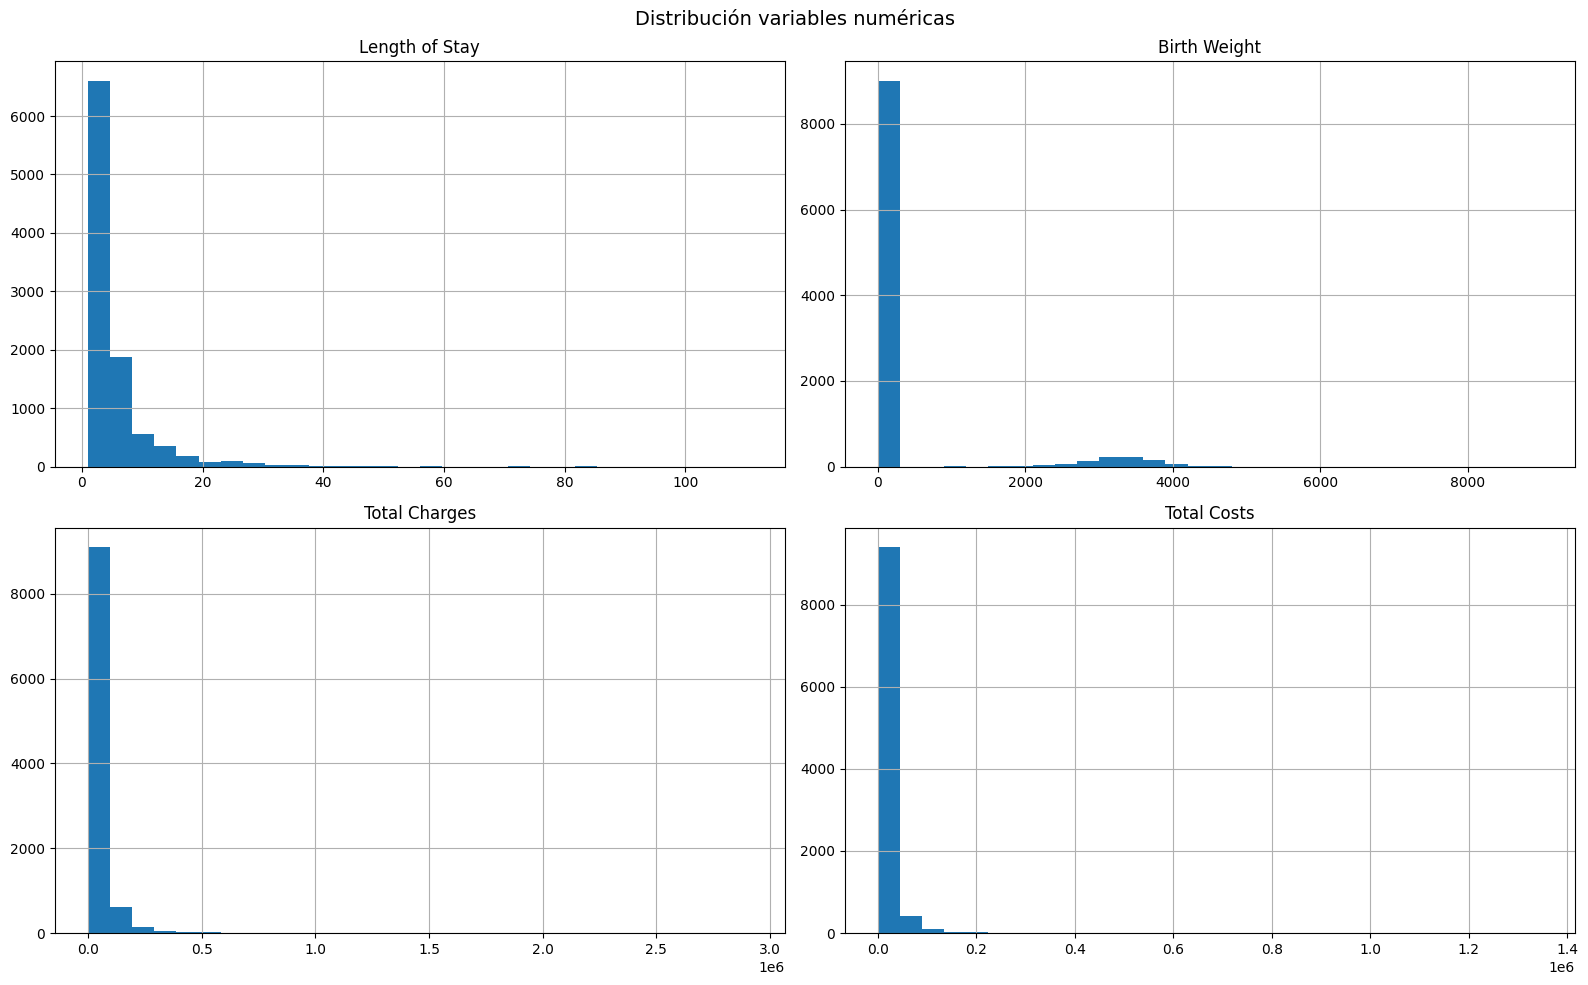

In [ ]:
#Histogramas variables numéricas:
num_cols = df.select_dtypes(include='number').columns.tolist()

df[num_cols].hist(figsize=(16, 10), bins=30)
plt.suptitle("Distribución variables numéricas", fontsize=14)
plt.tight_layout()
plt.show()

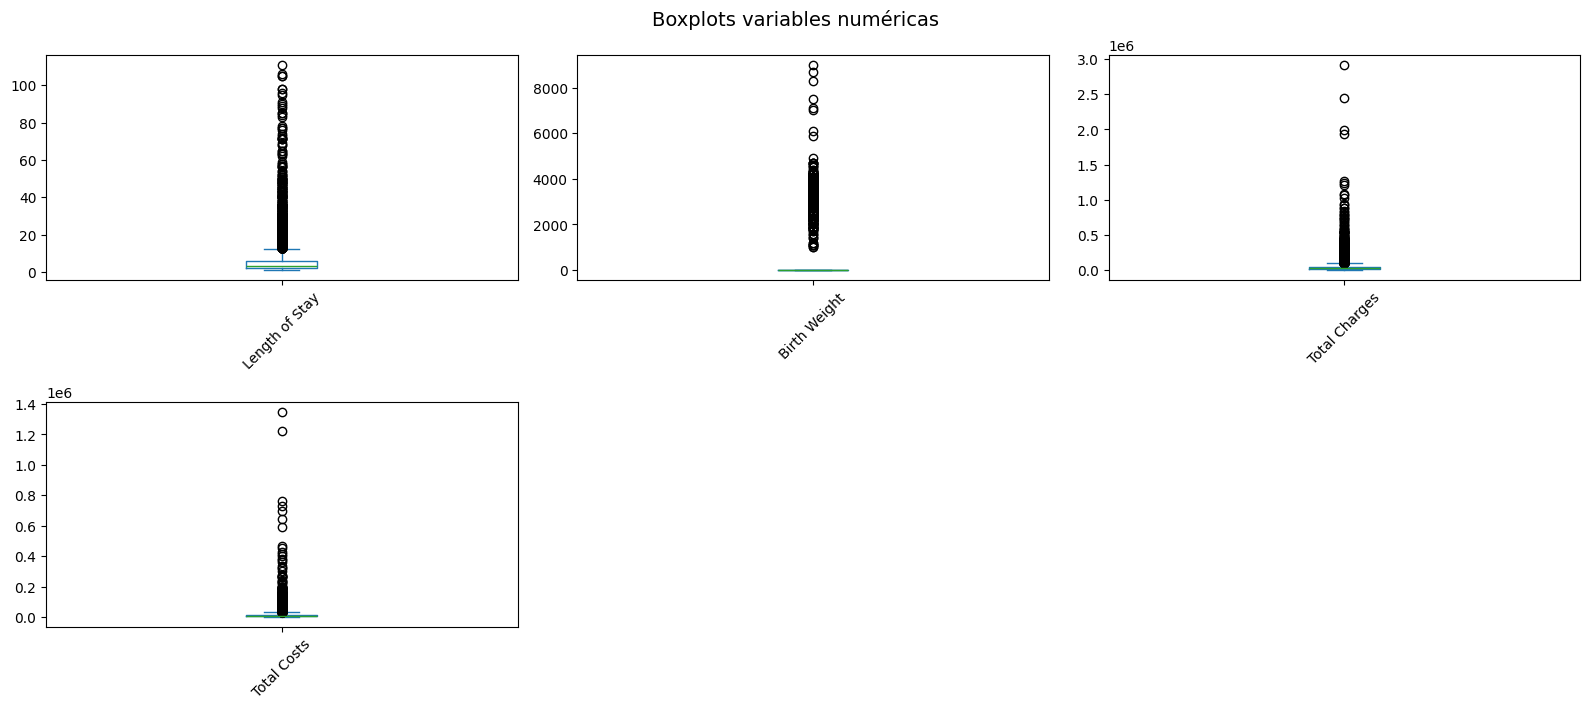

In [ ]:
#Boxplots variables numéricas
df[num_cols].plot(kind='box', figsize=(16, 10), rot=45, subplots=True, layout=(3, 3)) # Changed layout to (3,3) to fit all 9 plots
plt.suptitle("Boxplots variables numéricas", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
#Variables categóricas
cat_cols = df.select_dtypes(include='category').columns.tolist()

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Health Service Area:
Health Service Area
New York City     4559
Long Island       1491
Hudson Valley     1116
Western NY         725
Capital/Adiron     723
Central NY         650
Finger Lakes       609
Southern Tier      114
Name: count, dtype: int64

Hospital County:
Hospital County
Manhattan      1651
Kings          1042
Queens          830
Nassau          796
Bronx           793
Suffolk         695
Westchester     527
Erie            508
Monroe          438
Onondaga        321
Albany          286
Richmond        243
Orange          190
Rockland        158
Dutchess        144
Oneida          112
Broome          109
Schenectady      90
Niagara          85
Otsego           63
Chemung          61
Chautauqua       53
Warren           53
Ulster           48
St Lawrence      47
Jefferson        46
Rensselaer       44
Saratoga         44
Ontario          43
Clinton          42
Cattaraugus      30
Columbia         29
Tompkins         28
Montgomery       26
Wayne            26
Cayuga        

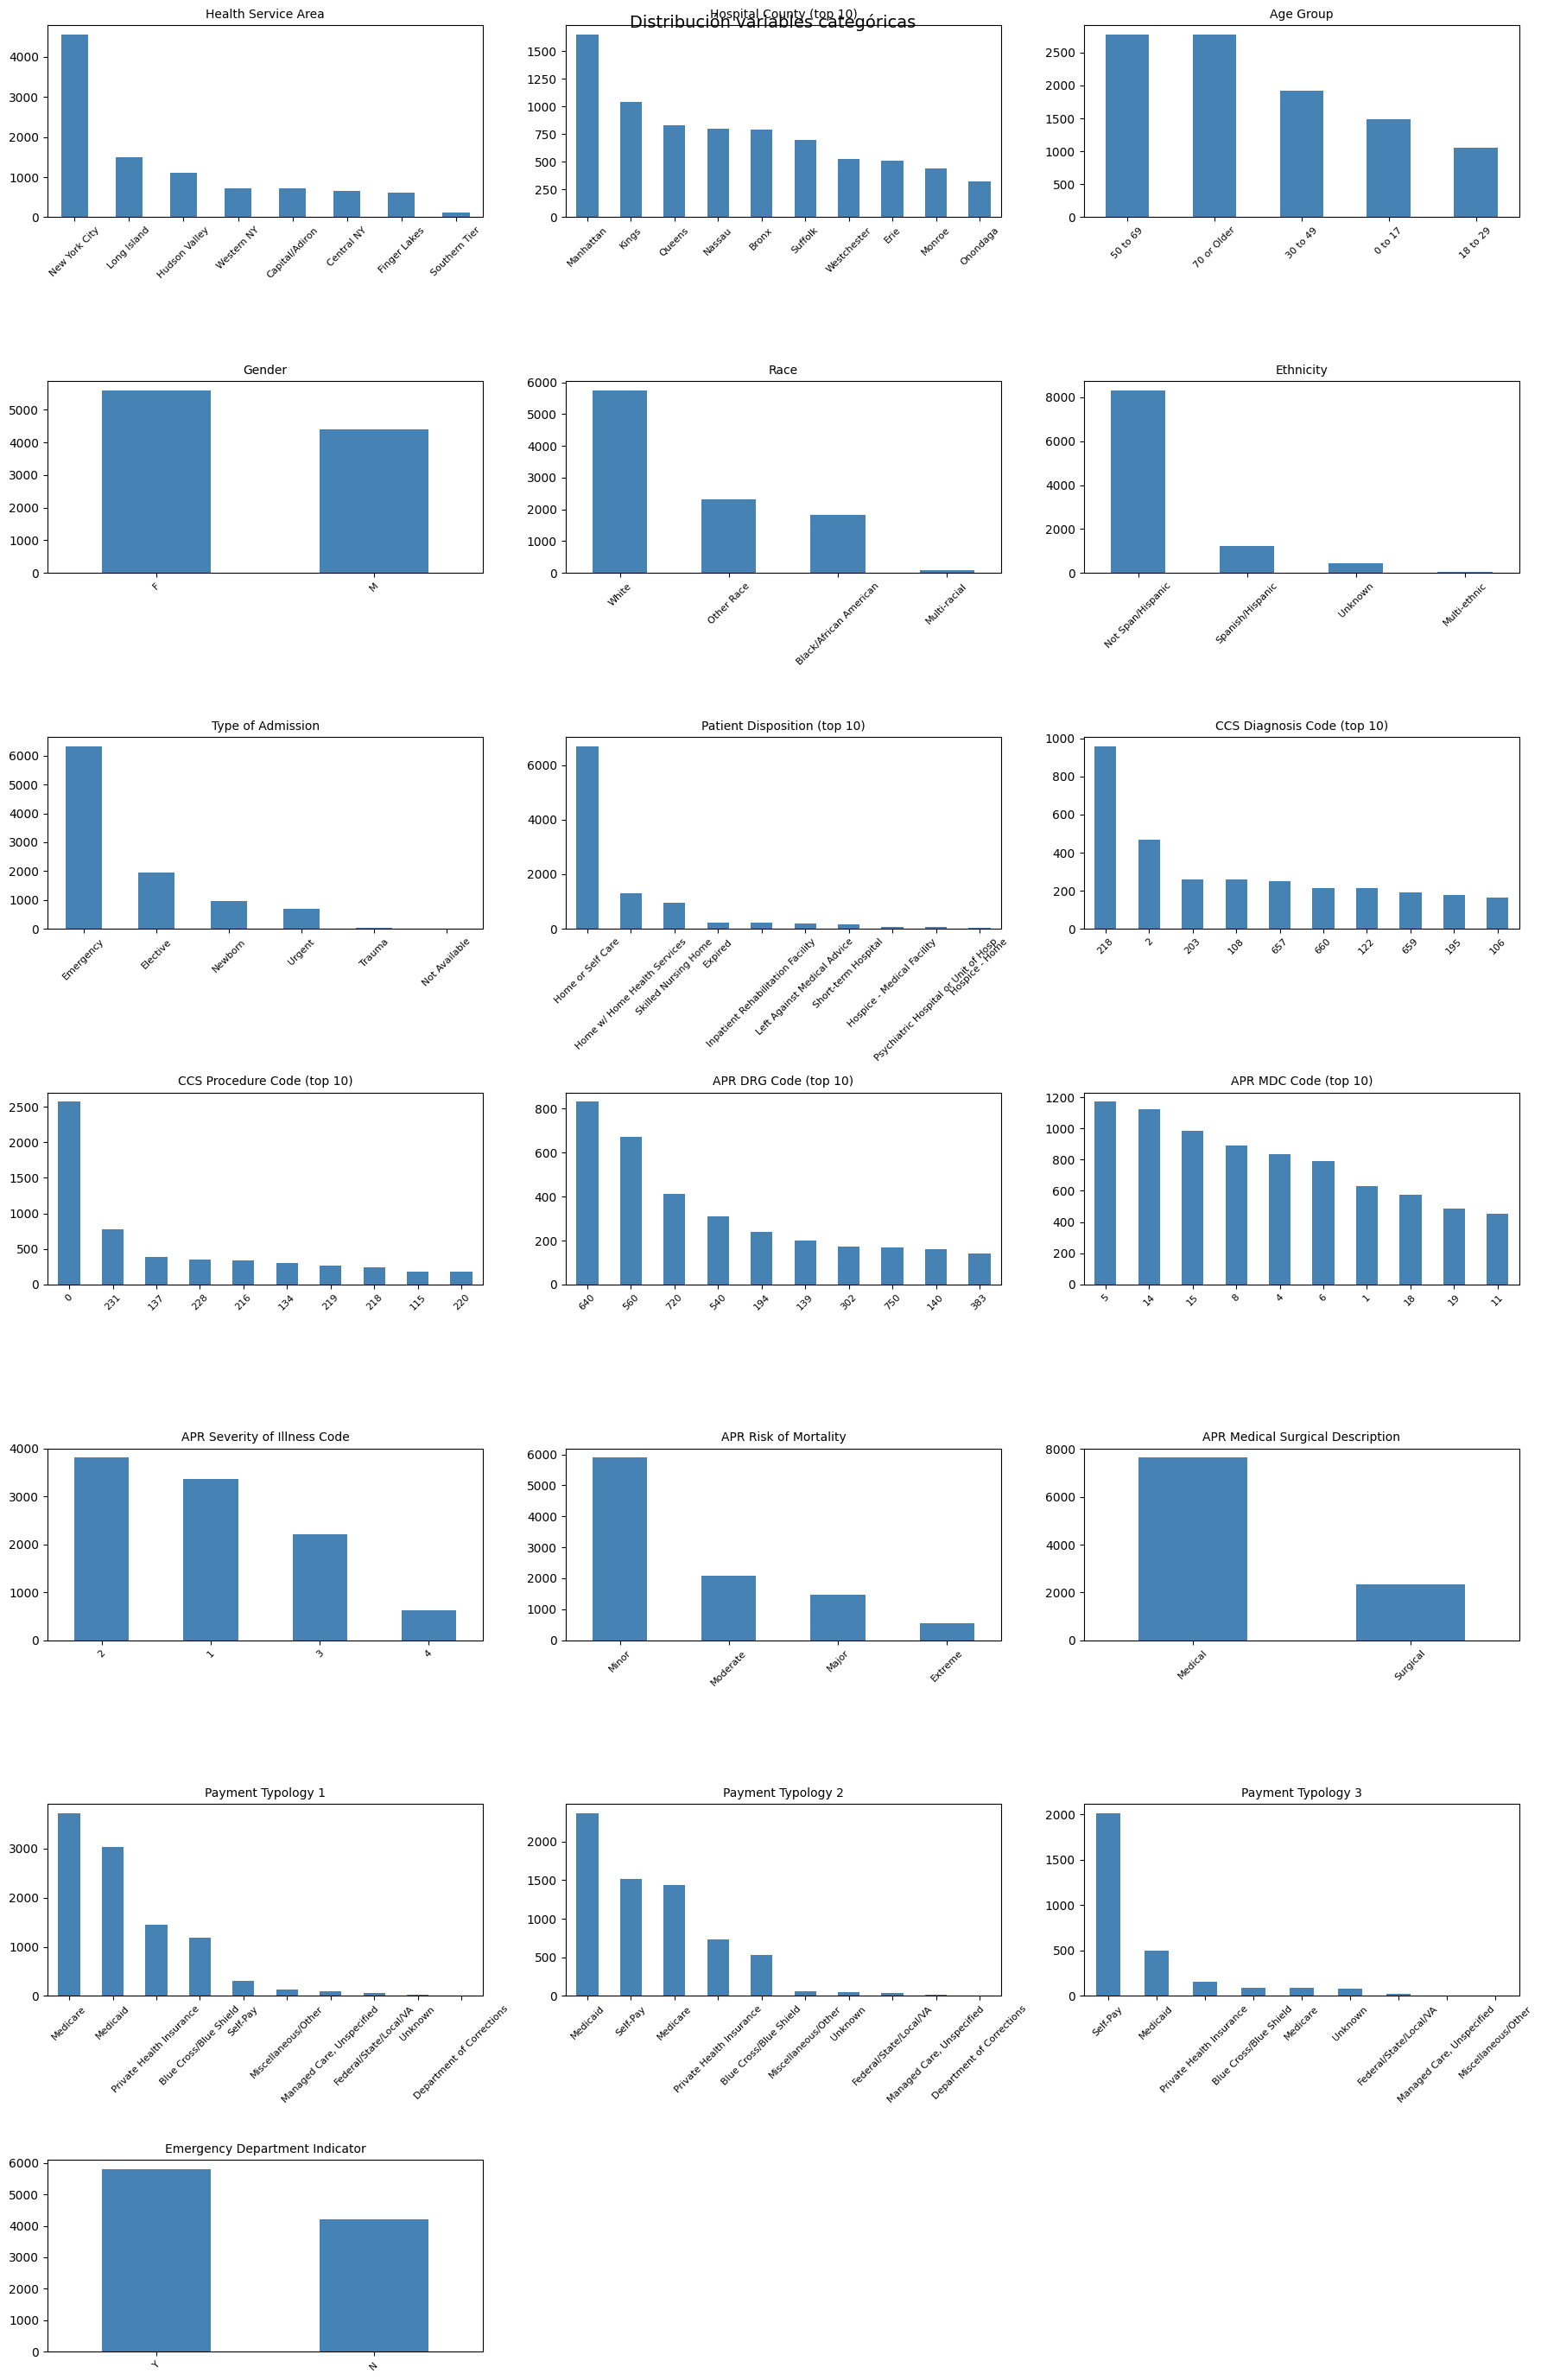

In [ ]:
#Visualización
n_cols = 3
n_rows = -(-len(cat_cols) // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    # Si tiene muchas categorías mostrar solo top 10
    if len(counts) > 10:
        counts = counts.head(10)
        axes[i].set_title(f"{col} (top 10)", fontsize=10)
    else:
        axes[i].set_title(col, fontsize=10)

    counts.plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)

# Ocultar ejes sobrantes si el grid tiene celdas vacías
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribución variables categóricas", fontsize=14)
plt.tight_layout()
plt.show()

array([[<Axes: xlabel='Length of Stay', ylabel='Length of Stay'>,
        <Axes: xlabel='Birth Weight', ylabel='Length of Stay'>,
        <Axes: xlabel='Total Charges', ylabel='Length of Stay'>,
        <Axes: xlabel='Total Costs', ylabel='Length of Stay'>],
       [<Axes: xlabel='Length of Stay', ylabel='Birth Weight'>,
        <Axes: xlabel='Birth Weight', ylabel='Birth Weight'>,
        <Axes: xlabel='Total Charges', ylabel='Birth Weight'>,
        <Axes: xlabel='Total Costs', ylabel='Birth Weight'>],
       [<Axes: xlabel='Length of Stay', ylabel='Total Charges'>,
        <Axes: xlabel='Birth Weight', ylabel='Total Charges'>,
        <Axes: xlabel='Total Charges', ylabel='Total Charges'>,
        <Axes: xlabel='Total Costs', ylabel='Total Charges'>],
       [<Axes: xlabel='Length of Stay', ylabel='Total Costs'>,
        <Axes: xlabel='Birth Weight', ylabel='Total Costs'>,
        <Axes: xlabel='Total Charges', ylabel='Total Costs'>,
        <Axes: xlabel='Total Costs', ylabel='Tota

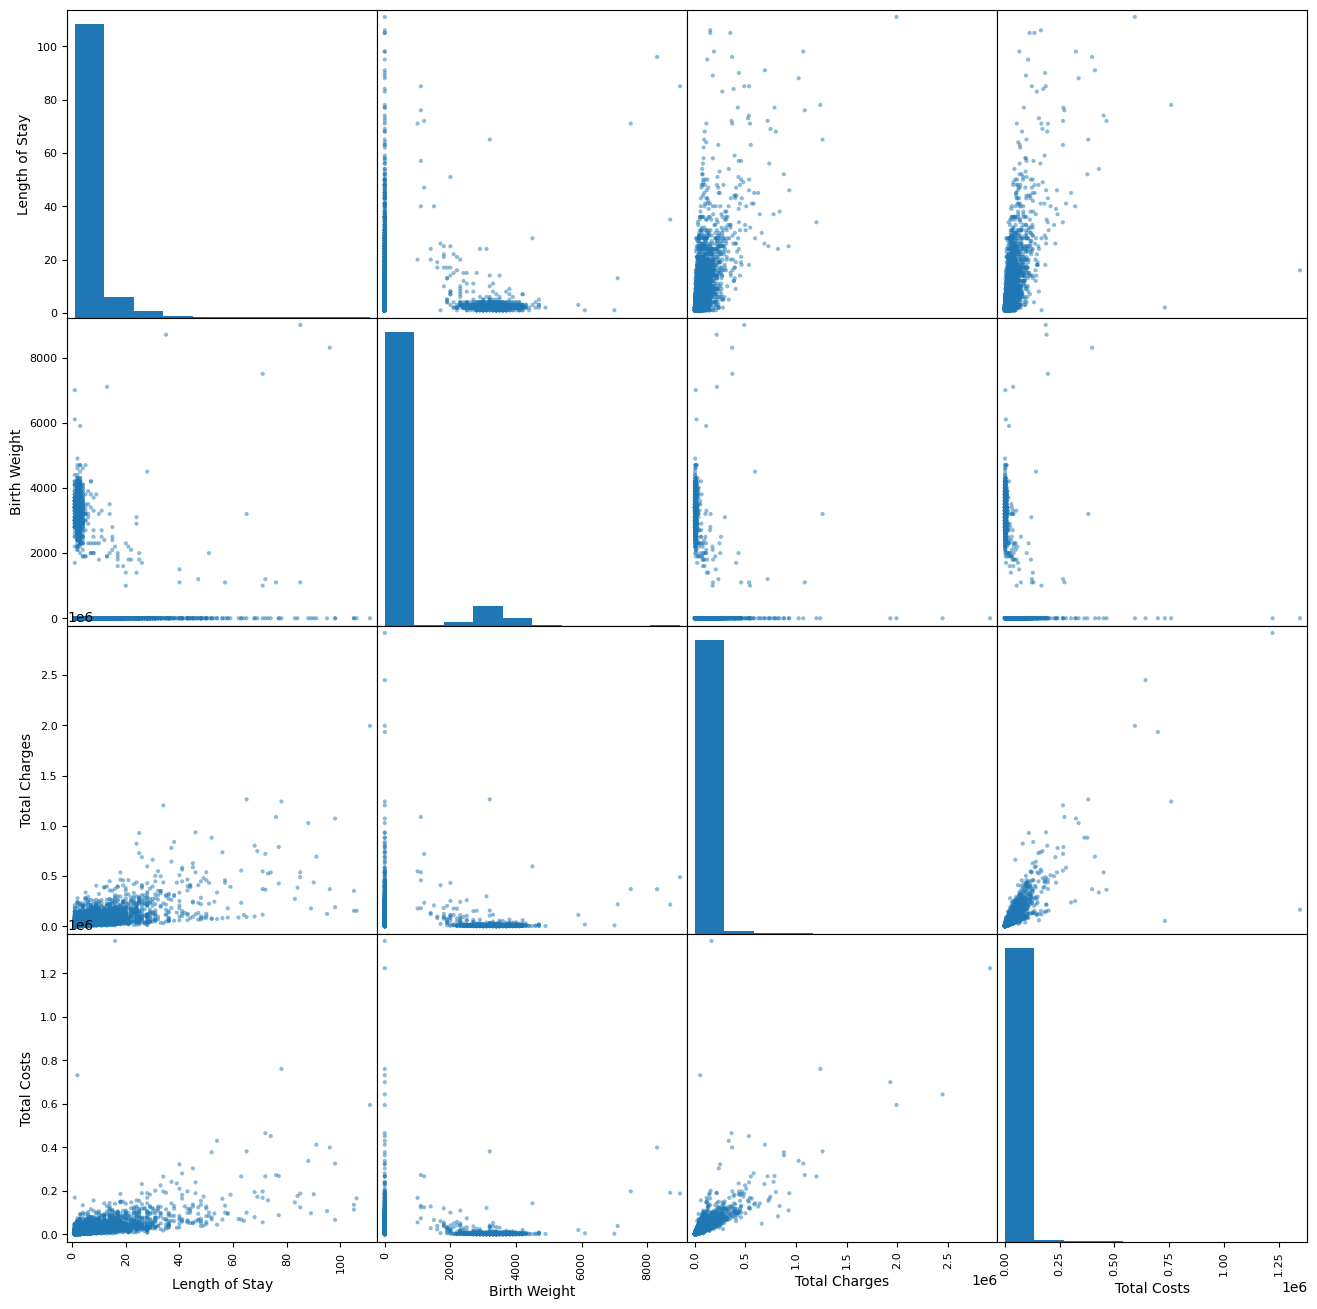

In [ ]:
pd.plotting.scatter_matrix(df, figsize=(16, 16))

**6. LImpieza de datos atípicos**

In [ ]:
#Duplicados:
duplicados = df.duplicated().sum()
print(f"Duplicados encontrados: {duplicados}")
df = df.drop_duplicates()
print(f"Shape tras eliminar duplicados: {df.shape}")

Duplicados encontrados: 0
Shape tras eliminar duplicados: (10000, 23)


**6.1 Análisis + limpieza outliers**

In [ ]:
print("=== Length of Stay ===")
print(f"Min: {df['Length of Stay'].min()}, Max: {df['Length of Stay'].max()}")
# Regla: debe ser >= 1 (el dataset SPARCS garantiza mínimo 1 día)
# Valores 0 provienen del fillna(0) aplicado en integración — son errores
errores_los = df[df["Length of Stay"] == 0]
print(f"Registros con Length of Stay = 0 (error de carga): {len(errores_los)}")

=== Length of Stay ===
Min: 1.0, Max: 111.0
Registros con Length of Stay = 0 (error de carga): 0


In [ ]:
print("=== Birth Weight ===")
print(f"Min: {df['Birth Weight'].min()}, Max: {df['Birth Weight'].max()}")
print(f"Registros con Birth Weight = 0: {(df['Birth Weight'] == 0).sum()}")
# Birth Weight = 0 es válido para pacientes no neonatos — no es un error
# Es el valor por defecto cuando el paciente no es un recién nacido
print("Birth Weight = 0 representa pacientes no neonatos, no es un error")

=== Birth Weight ===
Min: 0, Max: 9000
Registros con Birth Weight = 0: 9010
Birth Weight = 0 representa pacientes no neonatos, no es un error


In [ ]:
print("=== Total Charges y Total Costs ===")
print(df[["Total Charges", "Total Costs"]].describe())
# Valores negativos serían errores — verificar
print(f"\nTotal Charges negativos: {(df['Total Charges'] < 0).sum()}")
print(f"Total Costs negativos: {(df['Total Costs'] < 0).sum()}")

=== Total Charges y Total Costs ===
       Total Charges   Total Costs
count   1.000000e+04  1.000000e+04
mean    4.374987e+04  1.613762e+04
std     8.302903e+04  3.410433e+04
min     1.350000e+02  3.441000e+01
25%     1.201934e+04  4.759443e+03
50%     2.329550e+04  8.669570e+03
75%     4.735830e+04  1.661557e+04
max     2.918543e+06  1.348065e+06

Total Charges negativos: 0
Total Costs negativos: 0


In [ ]:
#Análisis IQR
# --- 4.4 Atípicos en variables numéricas continuas ---
num_cols_reales = ["Length of Stay", "Total Charges", "Total Costs"]

for col in num_cols_reales:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    atipicos = df[(df[col] < limite_inf) | (df[col] > limite_sup)]
    print(f"=== {col} ===")
    print(f"  Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
    print(f"  Límite inferior: {limite_inf:.2f} | Límite superior: {limite_sup:.2f}")
    print(f"  Atípicos encontrados: {len(atipicos)} ({len(atipicos)/len(df)*100:.2f}%)")
    print(f"  Valores atípicos min: {atipicos[col].min():.2f} | max: {atipicos[col].max():.2f}")
    print()

# --- Birth Weight: analizar solo neonatos (Birth Weight > 0) ---
bw_neonatos = df[df["Birth Weight"] > 0]["Birth Weight"]

Q1 = bw_neonatos.quantile(0.25)
Q3 = bw_neonatos.quantile(0.75)
IQR = Q3 - Q1
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

atipicos_bw = bw_neonatos[(bw_neonatos < limite_inf) | (bw_neonatos > limite_sup)]

print(f"=== Birth Weight (solo neonatos: {len(bw_neonatos)} registros) ===")
print(f"  Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
print(f"  Límite inferior: {limite_inf:.2f} | Límite superior: {limite_sup:.2f}")
print(f"  Atípicos encontrados: {len(atipicos_bw)} ({len(atipicos_bw)/len(bw_neonatos)*100:.2f}%)")
print(f"  Valores atípicos min: {atipicos_bw.min():.2f} | max: {atipicos_bw.max():.2f}")

=== Length of Stay ===
  Q1: 2.00 | Q3: 6.00 | IQR: 4.00
  Límite inferior: -4.00 | Límite superior: 12.00
  Atípicos encontrados: 848 (8.48%)
  Valores atípicos min: 13.00 | max: 111.00

=== Total Charges ===
  Q1: 12019.34 | Q3: 47358.30 | IQR: 35338.96
  Límite inferior: -40989.10 | Límite superior: 100366.74
  Atípicos encontrados: 864 (8.64%)
  Valores atípicos min: 100421.03 | max: 2918543.24

=== Total Costs ===
  Q1: 4759.44 | Q3: 16615.57 | IQR: 11856.13
  Límite inferior: -13024.75 | Límite superior: 34399.76
  Atípicos encontrados: 922 (9.22%)
  Valores atípicos min: 34400.61 | max: 1348064.82

=== Birth Weight (solo neonatos: 990 registros) ===
  Q1: 2900.00 | Q3: 3600.00 | IQR: 700.00
  Límite inferior: 1850.00 | Límite superior: 4650.00
  Atípicos encontrados: 33 (3.33%)
  Valores atípicos min: 1000.00 | max: 9000.00


In [ ]:
print("=== Gender ===")
print(df["Gender"].value_counts())
# Valores válidos: M, F — cualquier otro es error

=== Gender ===
Gender
F    5602
M    4398
Name: count, dtype: int64


In [ ]:
#Distribución de los bebés
print(f"Total neonatos (Birth Weight > 0): {(df['Birth Weight'] > 0).sum()}")
print(f"Total no neonatos (Birth Weight = 0): {(df['Birth Weight'] == 0).sum()}")
print(f"\nDistribución Birth Weight neonatos:")
print(df[df['Birth Weight'] > 0]['Birth Weight'].describe())

Total neonatos (Birth Weight > 0): 990
Total no neonatos (Birth Weight = 0): 9010

Distribución Birth Weight neonatos:
count     990.000000
mean     3250.909091
std       681.841750
min      1000.000000
25%      2900.000000
50%      3300.000000
75%      3600.000000
max      9000.000000
Name: Birth Weight, dtype: float64


In [ ]:
# Birth Weight: imputar neonatos con peso > 6000g con la mediana de neonatos
mediana_bw = df[df['Birth Weight'] > 0]['Birth Weight'].median()
print(f"Mediana Birth Weight neonatos: {mediana_bw}g")

registros_atipicos_bw = ((df['Birth Weight'] > 0) & (df['Birth Weight'] > 6000)).sum()
print(f"Registros a imputar: {registros_atipicos_bw}")

df.loc[(df['Birth Weight'] > 0) & (df['Birth Weight'] > 6000), 'Birth Weight'] = mediana_bw

print(f"Max Birth Weight después de imputar: {df[df['Birth Weight'] > 0]['Birth Weight'].max()}g")
print(f"\nDataset tras limpieza de atípicos: {df.shape[0]} filas, {df.shape[1]} columnas")

Mediana Birth Weight neonatos: 3300.0g
Registros a imputar: 7
Max Birth Weight después de imputar: 5900g

Dataset tras limpieza de atípicos: 10000 filas, 23 columnas


**7. Limpieza de datos nulos**

In [ ]:
print("=== NULOS POR COLUMNA ===")
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje': nulos_pct
}).sort_values('Porcentaje', ascending=False)

print(resumen_nulos[resumen_nulos['Nulos'] > 0])

=== NULOS POR COLUMNA ===
                     Nulos  Porcentaje
Payment Typology 3    7040       70.40
Payment Typology 2    3246       32.46
Health Service Area     13        0.13
Hospital County         13        0.13
Length of Stay           6        0.06


In [ ]:
#Borrar variables con más de 15% de nulos
df = df.drop(columns=["Payment Typology 2", "Payment Typology 3"])
print(f"Tras eliminar Payment Typology 2 y 3: {df.shape[1]} columnas")

#Imputar categóricas con la moda
for col in ["Health Service Area", "Hospital County"]:
    moda = df[col].mode()[0]
    nulos_antes = df[col].isnull().sum()
    df[col] = df[col].fillna(moda)
    df[col] = df[col].cat.remove_unused_categories()
    print(f"{col}: {nulos_antes} nulos imputados con moda '{moda}'")

#Eliminar nulos de target
df = df.dropna(subset=["Length of Stay"])
print(f"Registros eliminados: 6")
print(f"\nDataset final Fase 5: {df.shape[0]} filas, {df.shape[1]} columnas")

Tras eliminar Payment Typology 2 y 3: 21 columnas
Health Service Area: 13 nulos imputados con moda 'New York City'
Hospital County: 13 nulos imputados con moda 'Manhattan'
Registros eliminados: 6

Dataset final Fase 5: 9994 filas, 21 columnas


In [ ]:
#Verificación final
print("\n=== NULOS RESTANTES ===")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nDataset tras limpieza de nulos: {df.shape[0]} filas, {df.shape[1]} columnas")


=== NULOS RESTANTES ===
Series([], dtype: int64)

Dataset tras limpieza de nulos: 9994 filas, 21 columnas


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9994 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   Health Service Area               9994 non-null   category
 1   Hospital County                   9994 non-null   category
 2   Age Group                         9994 non-null   category
 3   Gender                            9994 non-null   category
 4   Race                              9994 non-null   category
 5   Ethnicity                         9994 non-null   category
 6   Length of Stay                    9994 non-null   float64 
 7   Type of Admission                 9994 non-null   category
 8   Patient Disposition               9994 non-null   category
 9   CCS Diagnosis Code                9994 non-null   category
 10  CCS Procedure Code                9994 non-null   category
 11  APR DRG Code                      9994 non-null   category
 1

**8. Análisis de correlaciones**

In [ ]:
#Pefilado de datos:
!pip install ydata-profiling -q
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df,
    title="Reporte Exploratorio — SPARCS NY 2015",
    explorative=True,
    minimal=True
)

profile.to_file("reporte_exploratorio.html")
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 21/21 [00:00<00:00, 75.60it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
codigos = ["CCS Diagnosis Code", "CCS Procedure Code",
           "APR DRG Code", "APR MDC Code",
           "APR Severity of Illness Code"]

for col in codigos:
    print(f"{col}: {df[col].nunique()} categorías únicas")

CCS Diagnosis Code: 247 categorías únicas
CCS Procedure Code: 201 categorías únicas
APR DRG Code: 294 categorías únicas
APR MDC Code: 25 categorías únicas
APR Severity of Illness Code: 4 categorías únicas


In [ ]:
# Ver categorías únicas de cada código
for col in codigos:
    print(f"\n=== {col} ({df[col].nunique()} únicas) ===")
    print(sorted(df[col].cat.categories.tolist()))


=== CCS Diagnosis Code (247 únicas) ===
[2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 175, 177, 178, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 221, 222, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 23

In [ ]:
# ─────────────────────────────────────────────
# 6. CORRELACIONES PARA REDUNDANCIA
# ─────────────────────────────────────────────

# --- 6.1 Preparar dataset numérico para correlaciones ---
df_corr = df.copy()

# Frequency Encoding para categóricas con muchas categorías
cols_freq = [
    "CCS Diagnosis Code", "CCS Procedure Code", "APR DRG Code",
    "Hospital County", "Patient Disposition", "Health Service Area"
]

for col in cols_freq:
    freq_map = df_corr[col].value_counts(normalize=True)
    df_corr[col] = df_corr[col].map(freq_map).astype(float)
    print(f"{col}: frequency encoding aplicado ({df[col].nunique()} categorías → valores entre {df_corr[col].min():.4f} y {df_corr[col].max():.4f})")

# Dummies con drop_first=True para evitar correlaciones perfectas entre complementarias
# Esto elimina automáticamente Gender_M, Ethnicity_Spanish/Hispanic, etc.
cols_dummies = [
    "Age Group", "Gender", "Race", "Ethnicity",
    "Type of Admission", "APR MDC Code",
    "APR Severity of Illness Code", "APR Risk of Mortality",
    "APR Medical Surgical Description", "Payment Typology 1",
    "Emergency Department Indicator"
]

df_corr = pd.get_dummies(df_corr, columns=cols_dummies, drop_first=True, dtype=int)

# Target a numérico
df_corr["Length of Stay"] = pd.to_numeric(df_corr["Length of Stay"], errors="coerce")

print(f"\nShape para correlaciones: {df_corr.shape}")

CCS Diagnosis Code: frequency encoding aplicado (247 categorías → valores entre 0.0001 y 0.0962)
CCS Procedure Code: frequency encoding aplicado (201 categorías → valores entre 0.0001 y 0.2572)
APR DRG Code: frequency encoding aplicado (294 categorías → valores entre 0.0001 y 0.0832)
Hospital County: frequency encoding aplicado (57 categorías → valores entre 0.0001 y 0.1664)
Patient Disposition: frequency encoding aplicado (17 categorías → valores entre 0.0001 y 0.6706)
Health Service Area: frequency encoding aplicado (8 categorías → valores entre 0.0114 y 0.4571)

Shape para correlaciones: (9994, 67)


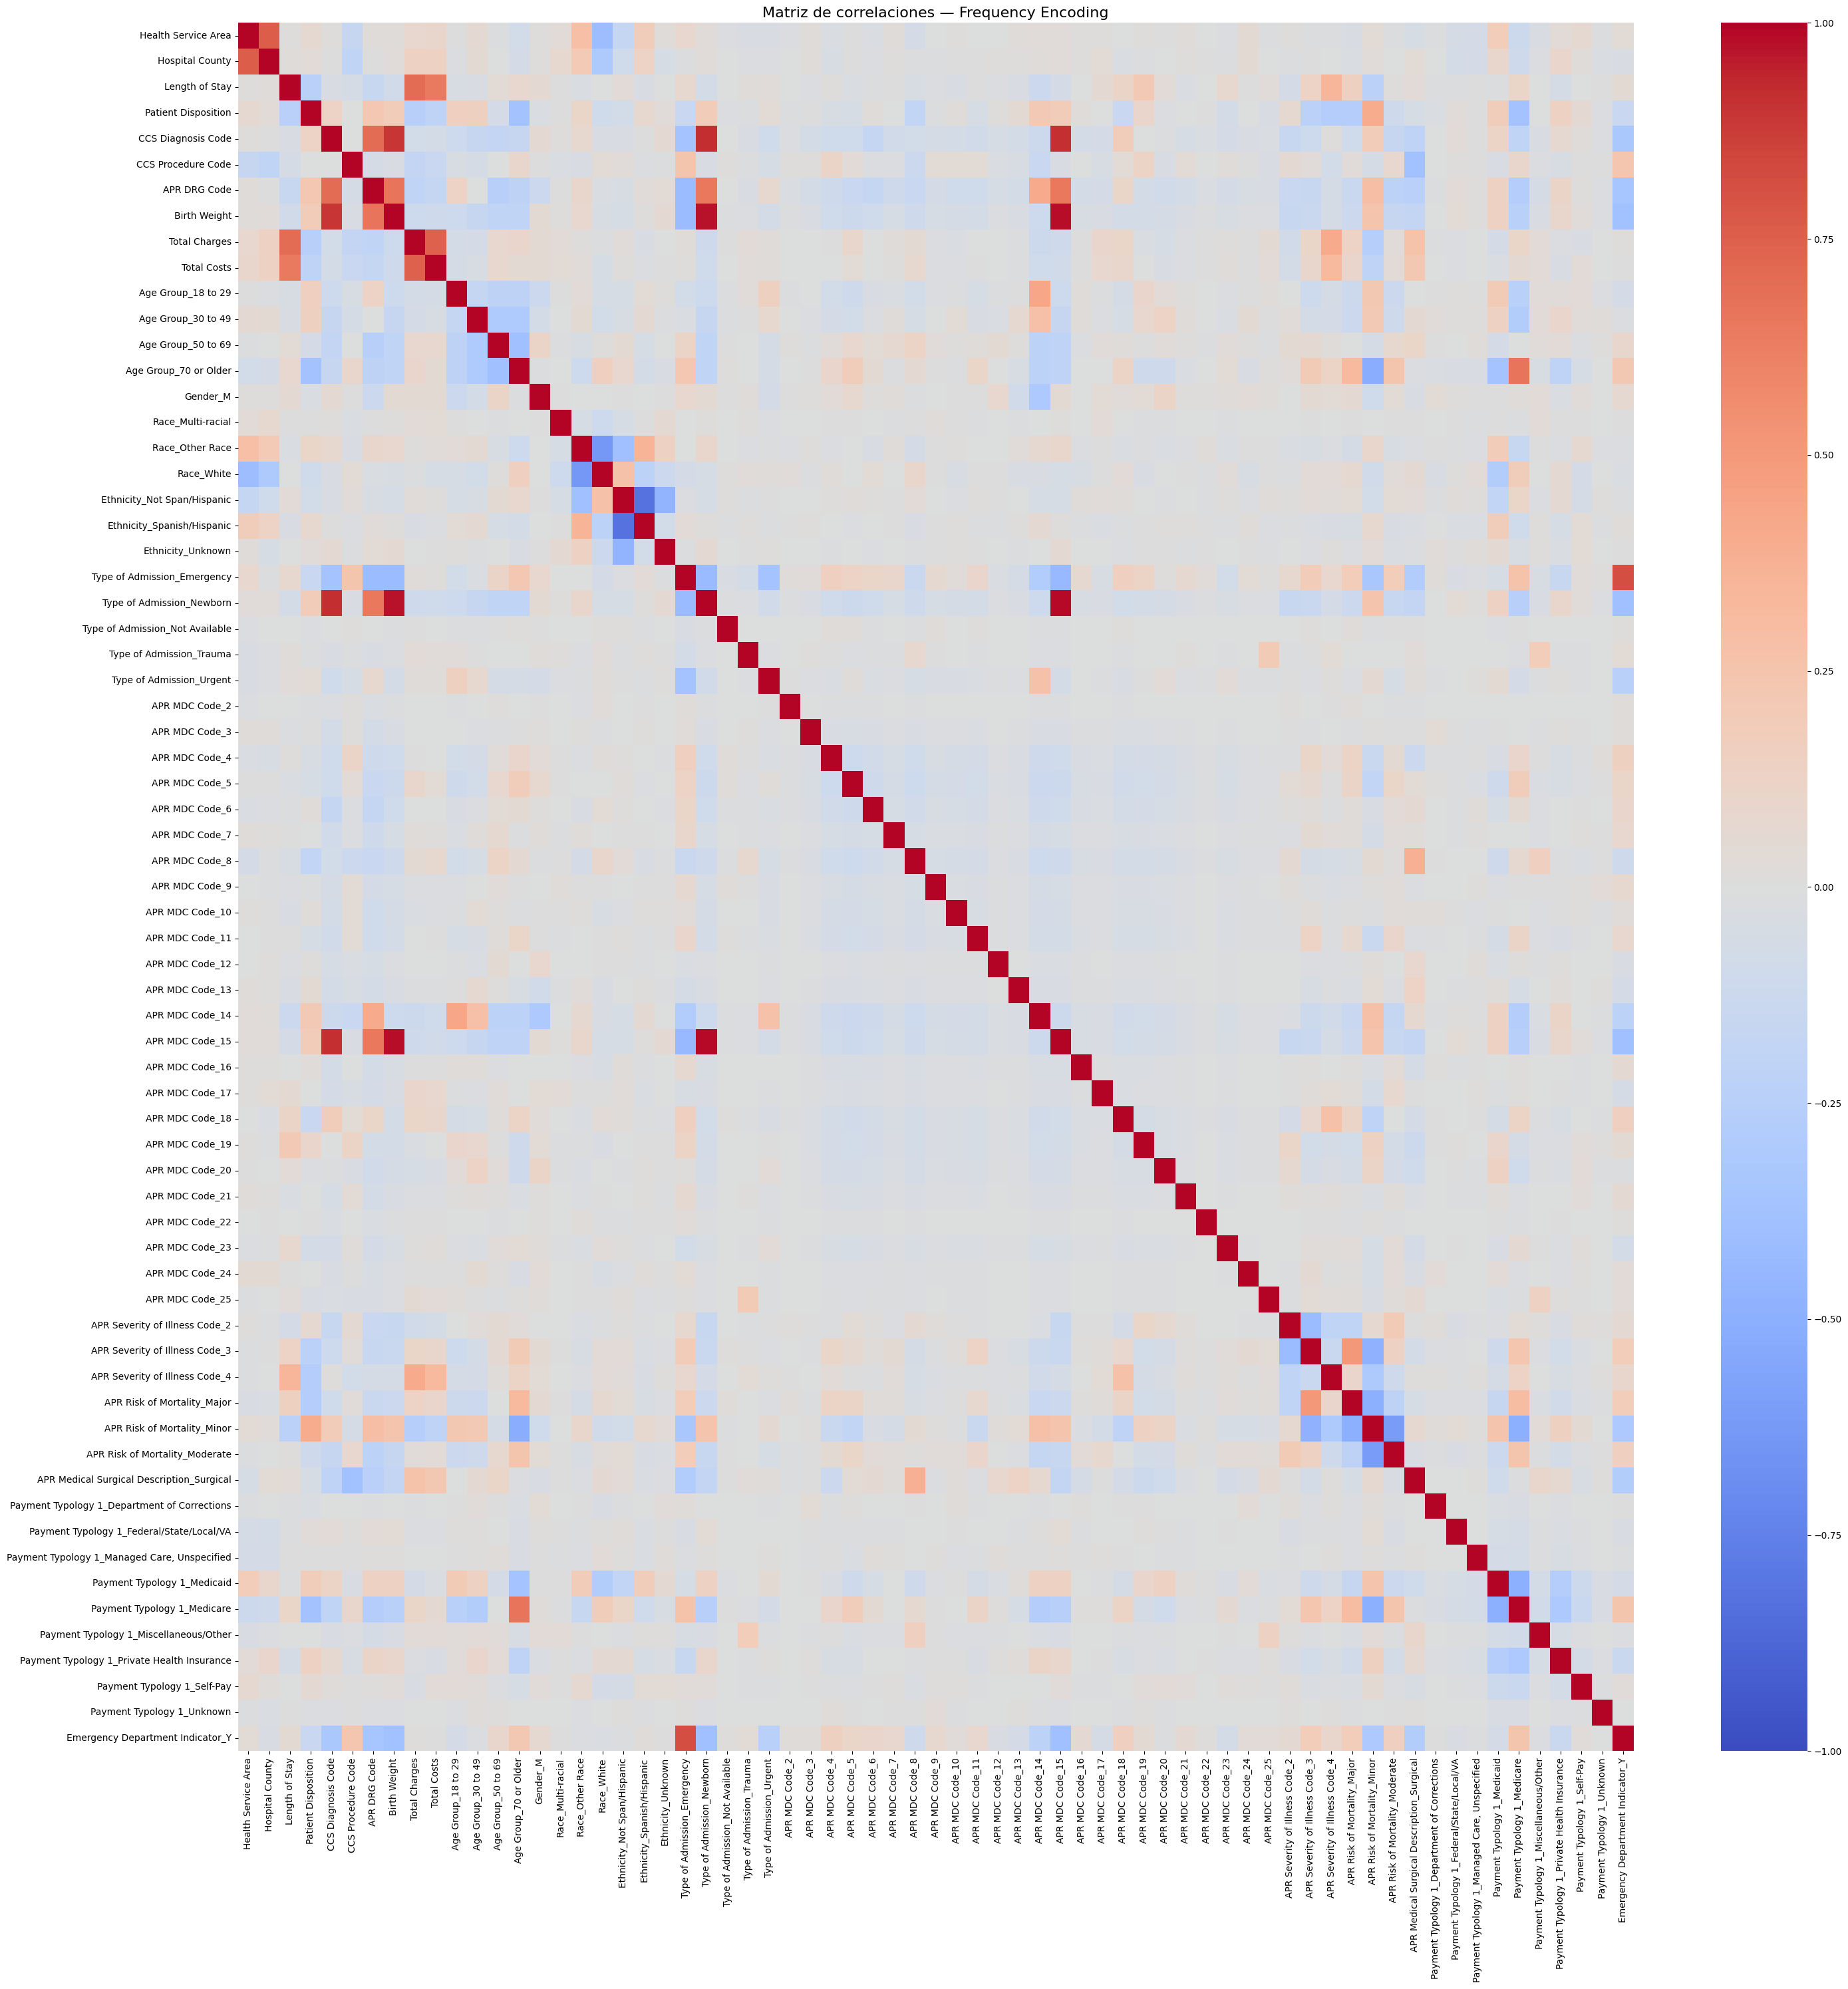

In [ ]:
# --- 6.2 Matriz de correlaciones ---
correlaciones = df_corr.corr(numeric_only=True)

plt.figure(figsize=(30, 30))
sns.heatmap(
    correlaciones,
    annot=False,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1
)
plt.title("Matriz de correlaciones — Frequency Encoding", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# --- 6.3 Pares con correlación > |0.8| (redundancia) ---
print("Pares de variables con correlación > |0.8|:")
pares_alta_correlacion = []

for i in range(len(correlaciones.columns)):
    for j in range(i + 1, len(correlaciones.columns)):
        if abs(correlaciones.iloc[i, j]) > 0.8:
            pares_alta_correlacion.append((
                correlaciones.columns[i],
                correlaciones.columns[j],
                correlaciones.iloc[i, j]
            ))

if pares_alta_correlacion:
    for var1, var2, corr_value in pares_alta_correlacion:
        print(f"  {var1}  ↔  {var2}: {corr_value:.4f}")
else:
    print("No se encontraron pares con correlación > |0.8|")

Pares de variables con correlación > |0.8|:
  CCS Diagnosis Code  ↔  Birth Weight: 0.8915
  CCS Diagnosis Code  ↔  Type of Admission_Newborn: 0.9193
  CCS Diagnosis Code  ↔  APR MDC Code_15: 0.9092
  Birth Weight  ↔  Type of Admission_Newborn: 0.9701
  Birth Weight  ↔  APR MDC Code_15: 0.9792
  Ethnicity_Not Span/Hispanic  ↔  Ethnicity_Spanish/Hispanic: -0.8247
  Type of Admission_Emergency  ↔  Emergency Department Indicator_Y: 0.8184
  Type of Admission_Newborn  ↔  APR MDC Code_15: 0.9892


In [ ]:
# --- 6.5 Correlación de Pearson con el target ---
print("Correlación de Pearson con Length of Stay:")
correlacion_target = correlaciones["Length of Stay"].drop("Length of Stay")
correlacion_target = correlacion_target.abs().sort_values(ascending=False)
print(correlacion_target.round(4))

print("\nVariables con correlación < |0.05| con Length of Stay:")
print(correlacion_target[correlacion_target < 0.05])

Correlación de Pearson con Length of Stay:
Total Charges                                   0.6978
Total Costs                                     0.6425
APR Severity of Illness Code_4                  0.3458
Patient Disposition                             0.2344
APR Risk of Mortality_Minor                     0.2321
                                                 ...  
Payment Typology 1_Self-Pay                     0.0015
Payment Typology 1_Managed Care, Unspecified    0.0014
APR MDC Code_16                                 0.0010
APR MDC Code_11                                 0.0004
Payment Typology 1_Miscellaneous/Other          0.0002
Name: Length of Stay, Length: 66, dtype: float64

Variables con correlación < |0.05| con Length of Stay:
Emergency Department Indicator_Y                0.048616
Age Group_18 to 29                              0.046840
Age Group_50 to 69                              0.045562
APR MDC Code_8                                  0.043279
Ethnicity_Spanish/H

**MI**

In [ ]:
# ─────────────────────────────────────────────
# 7. CORRELACIONES PARA IRRELEVANCIA CON EL TARGET
# ─────────────────────────────────────────────

from sklearn.feature_selection import mutual_info_regression

# --- 7.1 Preparar X e y ---
# Length of Stay ya no tiene nulos (tratados en Fase 5)
X = df.drop(columns=["Length of Stay"])
y = df["Length of Stay"]

# --- 7.2 Identificar cuáles columnas son categóricas ---
categorical_mask = X.dtypes == "category"

# --- 7.3 Encodear categóricas para MI (solo para cálculo) ---
X_encoded = X.copy()
for col in X_encoded.select_dtypes("category").columns:
    X_encoded[col] = X_encoded[col].cat.codes

# --- 7.4 Calcular Mutual Information ---
mi_scores = mutual_info_regression(
    X_encoded,
    y,
    discrete_features=categorical_mask,
    random_state=42
)

mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print("=== MUTUAL INFORMATION CON Length of Stay ===")
print(mi_series.round(4))

=== MUTUAL INFORMATION CON Length of Stay ===
Total Costs                         0.3966
Total Charges                       0.3293
APR DRG Code                        0.2905
CCS Diagnosis Code                  0.2243
CCS Procedure Code                  0.1921
APR MDC Code                        0.1440
APR Severity of Illness Code        0.1401
APR Risk of Mortality               0.1086
Patient Disposition                 0.1015
Age Group                           0.0587
Type of Admission                   0.0517
Birth Weight                        0.0498
Payment Typology 1                  0.0474
Emergency Department Indicator      0.0267
Hospital County                     0.0083
Race                                0.0080
Health Service Area                 0.0058
APR Medical Surgical Description    0.0021
Gender                              0.0020
Ethnicity                           0.0000
dtype: float64


In [ ]:
eliminar = [
    "Ethnicity",                      # MI=0.0000, Pearson<0.05
    "Gender",                         # MI=0.0020, Pearson<0.05
    "APR Medical Surgical Description",# MI=0.0021, Pearson<0.05
    "Hospital County",                # MI=0.0083, Pearson<0.05
    "Race",                           # MI=0.0080, Pearson<0.05
    "Birth Weight",                   # Redundante con APR MDC Code y Type of Admission
    "Emergency Department Indicator",  # Redundante con Type of Admission
    "Health Service Area"
]

df = df.drop(columns=eliminar)
print(f"Columnas restantes: {df.shape[1]}")
print(f"\nVariables finales:")
print(df.columns.tolist())

Columnas restantes: 13

Variables finales:
['Age Group', 'Length of Stay', 'Type of Admission', 'Patient Disposition', 'CCS Diagnosis Code', 'CCS Procedure Code', 'APR DRG Code', 'APR MDC Code', 'APR Severity of Illness Code', 'APR Risk of Mortality', 'Payment Typology 1', 'Total Charges', 'Total Costs']


**Ingeniería de características**

In [ ]:
# ─────────────────────────────────────────────
# 8. INGENIERÍA DE CARACTERÍSTICAS
# ─────────────────────────────────────────────

# --- 8.1 Crear variable objetivo categórica ---
# Length of Stay numérico → 3 categorías
# Corta: 1-3 días
# Media: 4-7 días
# Larga: 8+ días

def categorizar_los(dias):
    if dias <= 3:
        return "Corta"
    elif dias <= 7:
        return "Media"
    else:
        return "Larga"

df["los_categoria"] = df["Length of Stay"].apply(categorizar_los)
df["los_categoria"] = df["los_categoria"].astype("category")

print("=== Distribución variable objetivo ===")
print(df["los_categoria"].value_counts())
print()
print(df["los_categoria"].value_counts(normalize=True).round(3))

# Eliminar Length of Stay numérico — ya no se necesita
df = df.drop(columns=["Length of Stay"])

=== Distribución variable objetivo ===
los_categoria
Corta    5573
Media    2637
Larga    1784
Name: count, dtype: int64

los_categoria
Corta    0.558
Media    0.264
Larga    0.179
Name: proportion, dtype: float64


In [ ]:
# --- 8.2 Eliminar variables con data leakage ---
# Patient Disposition, Total Charges, Total Costs solo están
# disponibles al momento del alta — no al momento de la predicción
df = df.drop(columns=["Patient Disposition", "Total Charges", "Total Costs"])

print(f"\nShape final: {df.shape}")
print(f"\nVariables finales:")
print(df.columns.tolist())


Shape final: (9994, 10)

Variables finales:
['Age Group', 'Type of Admission', 'CCS Diagnosis Code', 'CCS Procedure Code', 'APR DRG Code', 'APR MDC Code', 'APR Severity of Illness Code', 'APR Risk of Mortality', 'Payment Typology 1', 'los_categoria']


In [ ]:
df.to_csv("datos_preparados_base.csv", index=False)
print(f"\nCSV guardado: datos_preparados_base.csv")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")


CSV guardado: datos_preparados_base.csv
Filas: 9994 | Columnas: 10


In [ ]:
print("CCS Diagnosis Codes en el dataset:")
print(sorted(df["CCS Diagnosis Code"].astype(int).unique().tolist()))
print(f"\nTotal: {df['CCS Diagnosis Code'].nunique()}")

print("\nCCS Procedure Codes en el dataset:")
print(sorted(df["CCS Procedure Code"].astype(int).unique().tolist()))
print(f"\nTotal: {df['CCS Procedure Code'].nunique()}")

CCS Diagnosis Codes en el dataset:
[2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 175, 177, 178, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 221, 222, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239

In [ ]:
# ─────────────────────────────────────────────
# 8.2 Agrupación semántica CCS Diagnosis Code
# Fuente oficial: AHRQ CCS Category Names Full Labels
# https://hcup-us.ahrq.gov/toolssoftware/ccs/CCSCategoryNames_FullLabels.pdf
# ─────────────────────────────────────────────

dx_grupos = {
    **{c: "Infecciosas"              for c in range(1, 11)},    # 1-10
    **{c: "Cancer"                   for c in range(11, 46)},   # 11-45
    **{c: "Neoplasias_benignas"      for c in range(46, 48)},   # 46-47
    **{c: "Endocrinas_metabolicas"   for c in range(48, 65)},   # 48-64
    **{c: "Mentales"                 for c in list(range(650, 664)) + [670]},
    **{c: "Nervioso_sensorial"       for c in range(76, 96)},   # 76-95
    **{c: "Circulatorio"             for c in range(96, 122)},  # 96-121
    **{c: "Respiratorio"             for c in range(122, 135)}, # 122-134
    **{c: "Digestivo"                for c in range(135, 156)}, # 135-155
    **{c: "Genitourinario"           for c in range(156, 176)}, # 156-175
    **{c: "Embarazo_parto"           for c in range(176, 197)}, # 176-196
    **{c: "Piel"                     for c in range(197, 201)}, # 197-200
    **{c: "Musculoesqueletico"       for c in range(201, 213)}, # 201-212
    **{c: "Congenitas"               for c in range(213, 218)}, # 213-217
    **{c: "Perinatales"              for c in range(218, 225)}, # 218-224
    **{c: "Sintomas_mal_definidos"   for c in range(225, 245)}, # 225-244
    **{c: "Lesiones"                 for c in range(245, 260)}, # 245-259
    917: "Especiales"
}

df["CCS_DX_Grupo"] = df["CCS Diagnosis Code"].astype(int).map(dx_grupos).fillna("Otros").astype("category")

print("Grupos CCS Diagnosis:")
print(df["CCS_DX_Grupo"].value_counts())
print(f"\nCódigos sin mapear (Otros): {(df['CCS_DX_Grupo'] == 'Otros').sum()}")

Grupos CCS Diagnosis:
CCS_DX_Grupo
Circulatorio              1352
Embarazo_parto            1117
Perinatales                983
Mentales                   880
Digestivo                  800
Respiratorio               759
Sintomas_mal_definidos     756
Musculoesqueletico         559
Infecciosas                548
Endocrinas_metabolicas     542
Cancer                     418
Genitourinario             403
Nervioso_sensorial         313
Lesiones                   285
Piel                       168
Neoplasias_benignas         78
Congenitas                  32
Especiales                   1
Name: count, dtype: int64

Códigos sin mapear (Otros): 0


In [ ]:
# ─────────────────────────────────────────────
# 8.3 Agrupación semántica CCS Procedure Code
# Fuente: AHRQ CCS Category Names Full Labels
# https://hcup-us.ahrq.gov/toolssoftware/ccs/CCSCategoryNames_FullLabels.pdf
# Procedimientos 1-231 + código 0 (sin procedimiento) + 999 (otros SPARCS)
# ─────────────────────────────────────────────

pr_grupos = {
    0:   "Sin_procedimiento",                                     # 0
    **{c: "Sistema_nervioso"       for c in range(1, 10)},        # 1-9
    **{c: "Sistema_endocrino"      for c in range(10, 13)},       # 10-12
    **{c: "Ojos_oidos"             for c in range(13, 22)},       # 13-21
    **{c: "Cardiovascular"         for c in range(22, 48)},       # 22-47
    **{c: "Respiratorio"           for c in range(48, 56)},       # 48-55
    **{c: "Digestivo"              for c in range(56, 84)},       # 56-83
    **{c: "Urinario_renal"         for c in range(84, 101)},      # 84-100
    **{c: "Ginecologia_obstetricia" for c in range(101, 140)},    # 101-139
    **{c: "Musculoesqueletico"     for c in range(140, 168)},     # 140-167
    **{c: "Tegumentario"           for c in range(168, 176)},     # 168-175
    **{c: "Hematologia_inmunologia" for c in range(176, 182)},    # 176-181
    **{c: "Diagnostico"            for c in range(182, 210)},     # 182-209
    **{c: "Terapeutico_miscelaneo" for c in range(210, 232)},     # 210-231
    999: "Otros"
}

df["CCS_PR_Grupo"] = df["CCS Procedure Code"].astype(int).map(pr_grupos).fillna("Otros").astype("category")

print("Grupos CCS Procedure:")
print(df["CCS_PR_Grupo"].value_counts())
print(f"\nCódigos sin mapear (Otros): {(df['CCS_PR_Grupo'] == 'Otros').sum()}")

# Eliminar columnas originales
df = df.drop(columns=["CCS Diagnosis Code", "CCS Procedure Code"])
print(f"\nShape tras agrupación: {df.shape}")
print(df.columns.tolist())

Grupos CCS Procedure:
CCS_PR_Grupo
Terapeutico_miscelaneo     2743
Sin_procedimiento          2570
Ginecologia_obstetricia    1273
Musculoesqueletico          905
Digestivo                   639
Cardiovascular              452
Urinario_renal              360
Diagnostico                 347
Respiratorio                229
Hematologia_inmunologia     163
Sistema_nervioso            162
Tegumentario                126
Sistema_endocrino            18
Ojos_oidos                    6
Otros                         1
Name: count, dtype: int64

Códigos sin mapear (Otros): 1

Shape tras agrupación: (9994, 10)
['Age Group', 'Type of Admission', 'APR DRG Code', 'APR MDC Code', 'APR Severity of Illness Code', 'APR Risk of Mortality', 'Payment Typology 1', 'los_categoria', 'CCS_DX_Grupo', 'CCS_PR_Grupo']


In [ ]:
# ─────────────────────────────────────────────
# 9. GUARDAR DATOS PREPARADOS
# ─────────────────────────────────────────────
df.to_csv("datos_preparados_base.csv", index=False)
print(f"Dataset guardado: {df.shape[0]} filas, {df.shape[1]} columnas")
print(df.columns.tolist())

Dataset guardado: 9994 filas, 10 columnas
['Age Group', 'Type of Admission', 'APR DRG Code', 'APR MDC Code', 'APR Severity of Illness Code', 'APR Risk of Mortality', 'Payment Typology 1', 'los_categoria', 'CCS_DX_Grupo', 'CCS_PR_Grupo']
